# Regridding Benchmark: Sphedron vs xESMF

This notebook compares sparse interpolation methods from **sphedron** against
[xESMF](https://xesmf.readthedocs.io/) for transferring a scalar field between
two uniform lat-lon grids on the sphere.

We benchmark:
- **xESMF**: bilinear, nearest, conservative regridding
- **Sphedron**: nearest, IDW, Gaussian, local RBF (degree 0 and 1)

All sphedron methods produce a sparse weight matrix `W` such that `y = W @ x`,
which can be reused as a fixed linear layer in deep-learning pipelines.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe

from sphedron import UniformMesh
from sphedron.transfer import MeshTransfer
from sphedron.transform import xyz_to_thetaphi

## Setup

We create a 1° sender grid and a 0.5° receiver grid, both uniform lat-lon.
The test field is a spherical harmonic: $f(\theta, \varphi) = \cos(3\theta)\sin(2\varphi)$.

In [2]:
sender = UniformMesh(resolution=1.0)
receiver = UniformMesh(resolution=0.5)

tp_s = xyz_to_thetaphi(sender.nodes)
tp_r = xyz_to_thetaphi(receiver.nodes)

x_send = np.cos(3 * tp_s[:, 0]) * np.sin(2 * tp_s[:, 1])
y_true = np.cos(3 * tp_r[:, 0]) * np.sin(2 * tp_r[:, 1])
norm_true = np.linalg.norm(y_true)

print(f"Sender:   {sender.num_nodes:,} nodes (1°)")
print(f"Receiver: {receiver.num_nodes:,} nodes (0.5°)")

Sender:   64,800 nodes (1°)
Receiver: 259,200 nodes (0.5°)


Let's visualize the test field on the sender grid:

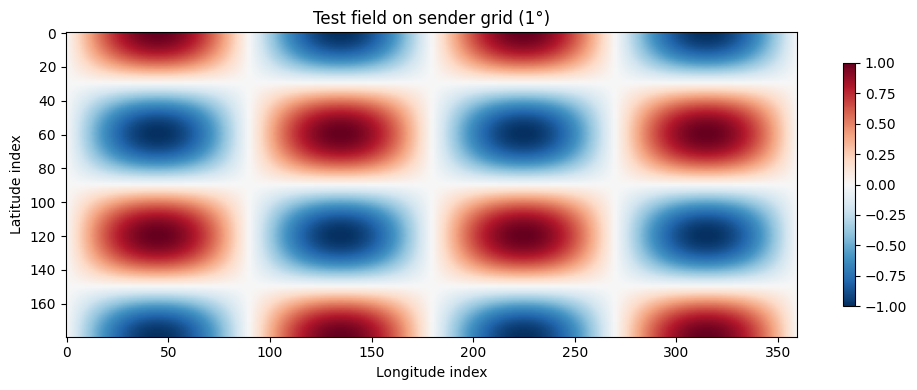

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
field_2d = sender.reshape(x_send)
im = ax.imshow(field_2d[::-1], aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Test field on sender grid (1°)")
ax.set_xlabel("Longitude index")
ax.set_ylabel("Latitude index")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## xESMF regridding

We build xesmf-compatible `xarray` datasets from the mesh coordinates
and benchmark bilinear, nearest, and conservative regridding.

In [4]:
# Extract lat/lon coordinates from the mesh node layout
n_lat_s, n_lon_s = 180, 360
n_lat_r, n_lon_r = 360, 720

lat_s = 90 - np.degrees(tp_s[:n_lat_s, 0])
lon_s = np.degrees(tp_s[::n_lat_s, 1]) % 360
lat_r = 90 - np.degrees(tp_r[:n_lat_r, 0])
lon_r = np.degrees(tp_r[::n_lat_r, 1]) % 360

ds_in = xr.Dataset({"lat": (["lat"], lat_s), "lon": (["lon"], lon_s)})
ds_out = xr.Dataset({"lat": (["lat"], lat_r), "lon": (["lon"], lon_r)})

# Reshape flat node values to (lat, lon) for xesmf
data_2d = x_send.reshape(n_lon_s, n_lat_s).T
da_in = xr.DataArray(data_2d, dims=["lat", "lon"],
                      coords={"lat": lat_s, "lon": lon_s})

In [5]:
import warnings
warnings.filterwarnings("ignore")

xesmf_results = {}

for method in ["bilinear", "nearest_s2d", "conservative"]:
    t0 = time.perf_counter()
    regridder = xe.Regridder(ds_in, ds_out, method, periodic=True)
    t_build = time.perf_counter() - t0

    t0 = time.perf_counter()
    result = regridder(da_in)
    t_apply = time.perf_counter() - t0

    y = result.values.T.ravel()  # back to node ordering
    delta = y - y_true
    rmse = np.sqrt(np.mean(delta ** 2))
    rel = np.linalg.norm(delta) / norm_true

    xesmf_results[method] = {
        "y": y, "rmse": rmse, "rel": rel,
        "build": t_build, "apply": t_apply,
    }
    print(f"xesmf {method:15s}  RMSE={rmse:.6e}  rel={rel:.4%}  "
          f"build={t_build:.3f}s  apply={t_apply:.4f}s")

xesmf bilinear         RMSE=2.635974e-02  rel=5.2719%  build=3.468s  apply=0.3509s


xesmf nearest_s2d      RMSE=7.865942e-03  rel=1.5732%  build=0.687s  apply=0.0119s


xesmf conservative     RMSE=7.858339e-03  rel=1.5717%  build=4.005s  apply=0.0197s


## Sphedron sparse transfer

`MeshTransfer.build_weights()` produces a sparse CSR matrix where each row
has a fixed number of non-zeros (the *degree*). The transfer is then a
single sparse matrix-vector product.

In [6]:
transfer = MeshTransfer(sender, receiver, n_neighbors=16)

sphedron_configs = [
    ("nearest",          dict(method="nearest")),
    ("idw(k=5)",         dict(method="idw", k=5)),
    ("gaussian(k=5)",    dict(method="gaussian", k=5)),
    ("local_rbf(k=8,d=0)",  dict(method="local_rbf", k=8, degree=0)),
    ("local_rbf(k=8,d=1)",  dict(method="local_rbf", k=8, degree=1)),
    ("local_rbf(k=16,d=0)", dict(method="local_rbf", k=16, degree=0)),
    ("local_rbf(k=16,d=1)", dict(method="local_rbf", k=16, degree=1)),
]

sphedron_results = {}

for name, kwargs in sphedron_configs:
    t0 = time.perf_counter()
    W = transfer.build_weights(**kwargs)
    t_build = time.perf_counter() - t0

    t0 = time.perf_counter()
    y = W @ x_send
    t_apply = time.perf_counter() - t0

    delta = y - y_true
    rmse = np.sqrt(np.mean(delta ** 2))
    rel = np.linalg.norm(delta) / norm_true
    nnz = W.nnz / W.shape[0]

    sphedron_results[name] = {
        "y": y, "rmse": rmse, "rel": rel,
        "build": t_build, "apply": t_apply, "nnz": nnz,
    }
    print(f"sphedron {name:20s}  RMSE={rmse:.6e}  rel={rel:.4%}  "
          f"build={t_build:.3f}s  apply={t_apply:.4f}s  nnz/row={nnz:.0f}")

sphedron nearest               RMSE=7.865942e-03  rel=1.5732%  build=0.094s  apply=0.0003s  nnz/row=1
sphedron idw(k=5)              RMSE=3.391504e-03  rel=0.6783%  build=0.030s  apply=0.0011s  nnz/row=5
sphedron gaussian(k=5)         RMSE=3.503608e-03  rel=0.7007%  build=0.041s  apply=0.0011s  nnz/row=5


sphedron local_rbf(k=8,d=0)    RMSE=2.438814e-03  rel=0.4878%  build=0.788s  apply=0.0013s  nnz/row=8


sphedron local_rbf(k=8,d=1)    RMSE=2.441545e-03  rel=0.4883%  build=1.415s  apply=0.0012s  nnz/row=8


sphedron local_rbf(k=16,d=0)   RMSE=7.509459e-03  rel=1.5019%  build=2.452s  apply=0.0023s  nnz/row=16


sphedron local_rbf(k=16,d=1)   RMSE=7.620532e-03  rel=1.5241%  build=3.384s  apply=0.0023s  nnz/row=16


## Comparison table

In [7]:
print(f"{'Method':<30s} {'RMSE':>12s} {'Rel. Error':>12s} {'Build':>8s} {'Apply':>8s}")
print("-" * 72)

for method, r in xesmf_results.items():
    print(f"xesmf {method:<24s} {r['rmse']:>12.6e} {r['rel']:>11.4%} "
          f"{r['build']:>7.3f}s {r['apply']:>7.4f}s")

print()
for name, r in sphedron_results.items():
    print(f"sphedron {name:<21s} {r['rmse']:>12.6e} {r['rel']:>11.4%} "
          f"{r['build']:>7.3f}s {r['apply']:>7.4f}s")

Method                                 RMSE   Rel. Error    Build    Apply
------------------------------------------------------------------------
xesmf bilinear                 2.635974e-02     5.2719%   3.468s  0.3509s
xesmf nearest_s2d              7.865942e-03     1.5732%   0.687s  0.0119s
xesmf conservative             7.858339e-03     1.5717%   4.005s  0.0197s

sphedron nearest               7.865942e-03     1.5732%   0.094s  0.0003s
sphedron idw(k=5)              3.391504e-03     0.6783%   0.030s  0.0011s
sphedron gaussian(k=5)         3.503608e-03     0.7007%   0.041s  0.0011s
sphedron local_rbf(k=8,d=0)    2.438814e-03     0.4878%   0.788s  0.0013s
sphedron local_rbf(k=8,d=1)    2.441545e-03     0.4883%   1.415s  0.0012s
sphedron local_rbf(k=16,d=0)   7.509459e-03     1.5019%   2.452s  0.0023s
sphedron local_rbf(k=16,d=1)   7.620532e-03     1.5241%   3.384s  0.0023s


## Error visualization

Let's compare the interpolation error spatially for the best method from each library.

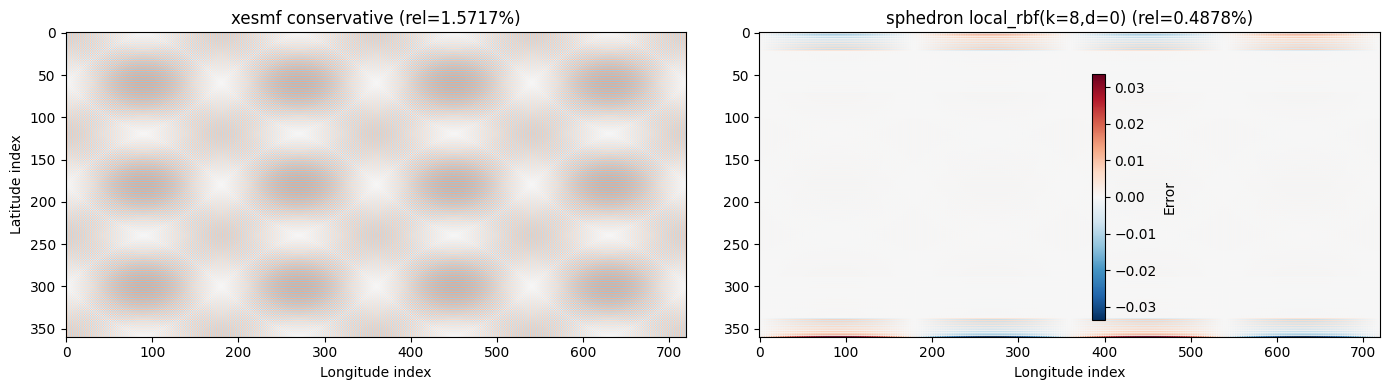

In [8]:
best_xesmf = xesmf_results["conservative"]["y"]
best_sphedron = sphedron_results["local_rbf(k=8,d=0)"]["y"]

err_xesmf = receiver.reshape(best_xesmf - y_true)
err_sphedron = receiver.reshape(best_sphedron - y_true)

vmax = max(np.abs(err_xesmf).max(), np.abs(err_sphedron).max())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im0 = axes[0].imshow(err_xesmf[::-1], aspect="auto", cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax)
axes[0].set_title(f"xesmf conservative (rel={xesmf_results['conservative']['rel']:.4%})")
axes[0].set_xlabel("Longitude index")
axes[0].set_ylabel("Latitude index")

im1 = axes[1].imshow(err_sphedron[::-1], aspect="auto", cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax)
axes[1].set_title(f"sphedron local_rbf(k=8,d=0) (rel={sphedron_results['local_rbf(k=8,d=0)']['rel']:.4%})")
axes[1].set_xlabel("Longitude index")

plt.colorbar(im1, ax=axes, shrink=0.8, label="Error")
plt.tight_layout()
plt.show()

## Bar chart comparison

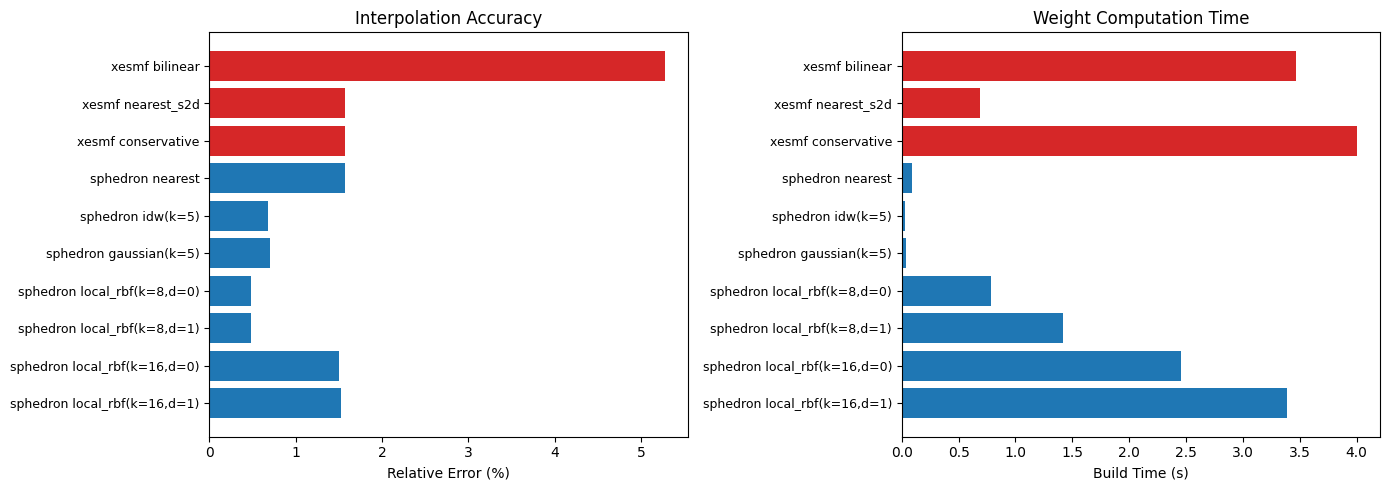

In [9]:
all_names = [f"xesmf {m}" for m in xesmf_results] + \
            [f"sphedron {n}" for n in sphedron_results]
all_rel = [r["rel"] * 100 for r in xesmf_results.values()] + \
          [r["rel"] * 100 for r in sphedron_results.values()]
all_build = [r["build"] for r in xesmf_results.values()] + \
            [r["build"] for r in sphedron_results.values()]

colors = ["#d62728"] * len(xesmf_results) + ["#1f77b4"] * len(sphedron_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(range(len(all_names)), all_rel, color=colors)
ax1.set_yticks(range(len(all_names)))
ax1.set_yticklabels(all_names, fontsize=9)
ax1.set_xlabel("Relative Error (%)")
ax1.set_title("Interpolation Accuracy")
ax1.invert_yaxis()

ax2.barh(range(len(all_names)), all_build, color=colors)
ax2.set_yticks(range(len(all_names)))
ax2.set_yticklabels(all_names, fontsize=9)
ax2.set_xlabel("Build Time (s)")
ax2.set_title("Weight Computation Time")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Icosphere sender (factor=64)

The previous benchmark used a uniform lat-lon sender grid, which xESMF is
designed for. Now let's use an **Icosphere** as the sender -- a triangular mesh
with quasi-uniform node spacing. xESMF requires structured grids, so it cannot
handle this case. Sphedron works on arbitrary point clouds.

In [10]:
from sphedron import Icosphere

ico = Icosphere.from_base(refine_factor=64)
print(f"Icosphere factor=64: {ico.num_nodes:,} nodes")
print(f"Receiver (same):     {receiver.num_nodes:,} nodes (0.5°)")

tp_ico = xyz_to_thetaphi(ico.nodes)
x_ico = np.cos(3 * tp_ico[:, 0]) * np.sin(2 * tp_ico[:, 1])

ico_transfer = MeshTransfer(ico, receiver, n_neighbors=16)

Icosphere factor=64: 40,962 nodes
Receiver (same):     259,200 nodes (0.5°)


In [11]:
# True field on receiver
y_true_ico = np.cos(3 * tp_r[:, 0]) * np.sin(2 * tp_r[:, 1])

ico_results = {}
for name, kw in sphedron_configs:
    t0 = time.perf_counter()
    W = ico_transfer.build_weights(**kw)
    build = time.perf_counter() - t0
    t0 = time.perf_counter()
    y = W @ x_ico
    apply = time.perf_counter() - t0
    delta = y - y_true_ico
    rmse = np.sqrt(np.mean(delta**2))
    rel = np.linalg.norm(delta) / np.linalg.norm(y_true_ico)
    ico_results[name] = dict(y=y, rmse=rmse, rel=rel, build=build, apply=apply,
                             nnz=W.nnz // W.shape[0])
    print(f"{name:<30s}  RMSE {rmse:.4e}  Rel {rel:.4%}  "
          f"Build {build:.3f}s  Apply {apply*1e3:.2f}ms")

nearest                         RMSE 7.4391e-02  Rel 14.8781%  Build 0.048s  Apply 0.43ms
idw(k=5)                        RMSE 7.1263e-02  Rel 14.2526%  Build 0.032s  Apply 1.12ms
gaussian(k=5)                   RMSE 6.3140e-02  Rel 12.6281%  Build 0.043s  Apply 1.12ms


local_rbf(k=8,d=0)              RMSE 5.2474e-02  Rel 10.4949%  Build 0.785s  Apply 1.29ms


local_rbf(k=8,d=1)              RMSE 5.2149e-02  Rel 10.4298%  Build 1.427s  Apply 1.27ms


local_rbf(k=16,d=0)             RMSE 5.3774e-02  Rel 10.7547%  Build 2.507s  Apply 2.40ms


local_rbf(k=16,d=1)             RMSE 5.3743e-02  Rel 10.7486%  Build 3.352s  Apply 2.38ms


In [12]:
print(f"{'Method':<30s} {'Uniform 1°':>14s} {'Icosphere f64':>14s}")
print("-" * 60)
for name in sphedron_results:
    u_rel = sphedron_results[name]["rel"]
    i_rel = ico_results.get(name, {}).get("rel", float("nan"))
    print(f"{name:<30s} {u_rel:>13.4%} {i_rel:>13.4%}")

Method                             Uniform 1°  Icosphere f64
------------------------------------------------------------
nearest                              1.5732%      14.8781%
idw(k=5)                             0.6783%      14.2526%
gaussian(k=5)                        0.7007%      12.6281%
local_rbf(k=8,d=0)                   0.4878%      10.4949%
local_rbf(k=8,d=1)                   0.4883%      10.4298%
local_rbf(k=16,d=0)                  1.5019%      10.7547%
local_rbf(k=16,d=1)                  1.5241%      10.7486%


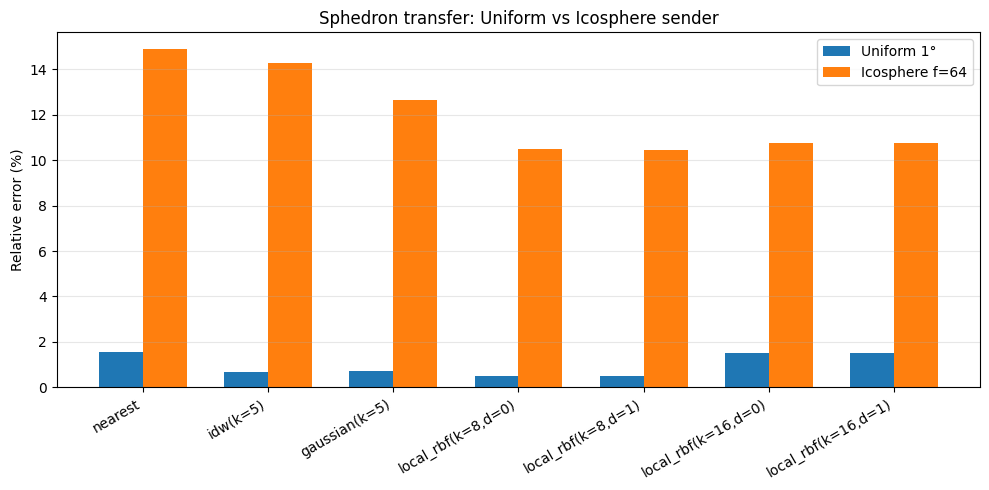

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(sphedron_results.keys())
x_pos = np.arange(len(names))
width = 0.35

uniform_rels = [sphedron_results[n]["rel"] * 100 for n in names]
ico_rels     = [ico_results[n]["rel"] * 100 for n in names]

ax.bar(x_pos - width/2, uniform_rels, width, label="Uniform 1°")
ax.bar(x_pos + width/2, ico_rels, width, label="Icosphere f=64")
ax.set_ylabel("Relative error (%)")
ax.set_title("Sphedron transfer: Uniform vs Icosphere sender")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Using the sparse weights in PyTorch

Since `W` is a fixed sparse matrix, the transfer `y = Wx` is differentiable
and can be used directly as a layer in a neural network.

In [14]:
import torch

W = transfer.build_weights(method="local_rbf", k=8, degree=0)

# Convert scipy sparse -> PyTorch sparse
W_coo = W.tocoo()
indices = torch.LongTensor(np.vstack([W_coo.row, W_coo.col]))
values = torch.FloatTensor(W_coo.data)
W_torch = torch.sparse_coo_tensor(indices, values, W_coo.shape)

# Forward + backward pass
x = torch.FloatTensor(x_send)
x.requires_grad_(True)

y = torch.sparse.mm(W_torch, x.unsqueeze(1)).squeeze(1)
loss = y.sum()
loss.backward()

print(f"Input:    {x.shape}")
print(f"Output:   {y.shape}")
print(f"Gradient: {x.grad.shape}  (nonzero: {(x.grad != 0).sum()}/{x.grad.shape[0]})")
print("\nGradients flow correctly through the sparse transfer.")

Input:    torch.Size([64800])
Output:   torch.Size([259200])
Gradient: torch.Size([64800])  (nonzero: 64800/64800)

Gradients flow correctly through the sparse transfer.
